<a href="https://colab.research.google.com/github/kpate18/ECGR-4105/blob/main/homework%203/Problem_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

First 5 rows:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Dataset Shape:
(768, 9)

Columns:
Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

Number of Features: 8

Training Samples: 614
Testing Samples: 154


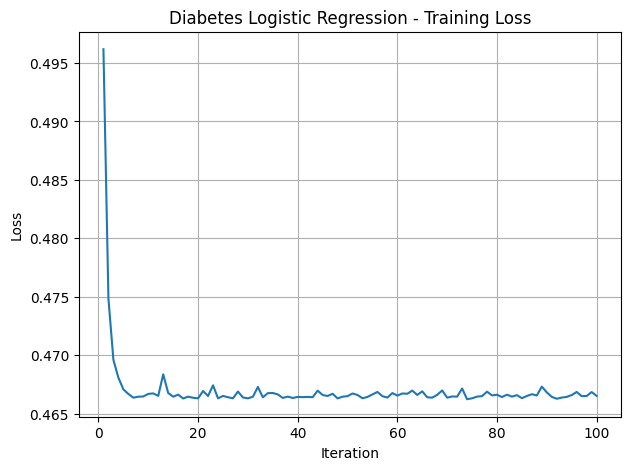

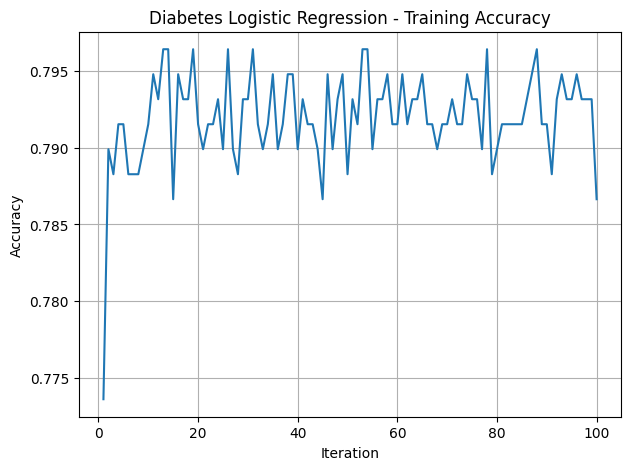


========== Diabetes Results ==========
Accuracy : 0.7078
Precision: 0.5957
Recall   : 0.5185
F1 Score : 0.5545


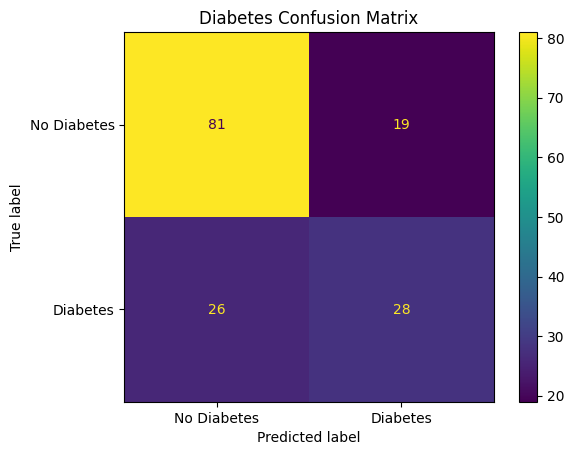

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    log_loss,
    ConfusionMatrixDisplay
)

# 1. Load Dataset
df = pd.read_csv("diabetes.csv")

print("First 5 rows:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns)


# 2. Separate Input Features and Output
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

print("\nNumber of Features:", X.shape[1])


# 3. Split Dataset (80% Training and 20% Testing)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining Samples:", len(X_train))
print("Testing Samples:", len(X_test))

# 4. Standardize the Data
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

y_train = y_train.to_numpy()
y_test = y_test.to_numpy()


# 5. Create Logistic Regression Model
model = SGDClassifier(
    loss="log_loss",
    penalty=None,
    learning_rate="constant",
    eta0=0.01,
    random_state=42
)

# 6. Train Model and Record Loss + Accuracy
epochs = 100

loss_history = []
accuracy_history = []

classes = np.array([0, 1])

rng = np.random.default_rng(42)

for epoch in range(epochs):

    # Shuffle training data
    index = rng.permutation(len(y_train))

    X_epoch = X_train[index]
    y_epoch = y_train[index]

    # Train one iteration
    model.partial_fit(
        X_epoch,
        y_epoch,
        classes=classes
    )

    # Calculate training probability
    y_probability = model.predict_proba(X_train)[:, 1]

    # Calculate training loss
    loss = log_loss(y_train, y_probability)

    # Calculate training accuracy
    y_train_pred = model.predict(X_train)

    accuracy = accuracy_score(
        y_train,
        y_train_pred
    )

    loss_history.append(loss)
    accuracy_history.append(accuracy)


# 7. Plot Training Loss
plt.figure(figsize=(7, 5))

plt.plot(
    range(1, epochs + 1),
    loss_history
)

plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Diabetes Logistic Regression - Training Loss")

plt.grid()
plt.show()


# 8. Plot Training Accuracy
plt.figure(figsize=(7, 5))

plt.plot(
    range(1, epochs + 1),
    accuracy_history
)

plt.xlabel("Iteration")
plt.ylabel("Accuracy")
plt.title("Diabetes Logistic Regression - Training Accuracy")

plt.grid()
plt.show()

# 9. Test the Model
y_pred = model.predict(X_test)

# 10. Calculate Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

# 11. Print Results


print("\n========== Diabetes Results ==========")

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))


# 12. Confusion Matrix

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=[
        "No Diabetes",
        "Diabetes"
    ]
)

plt.title("Diabetes Confusion Matrix")

plt.show()